<a href="https://colab.research.google.com/github/Gaurav9571/week1_Gaurav_Mittal/blob/main/Week3_GAURAV_MITTAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 50000

df = pd.DataFrame({

    "CustomerID": range(1,n+1),

    "Age": np.random.randint(18,70,n),

    "Gender": np.random.choice(
        ["Male","Female"],
        n
    ),

    "MaritalStatus": np.random.choice(
        ["Single","Married"],
        n
    ),

    "Education": np.random.choice(
        ["HighSchool","Bachelor","Master","PhD"],
        n
    ),

    "Occupation": np.random.choice(
        ["Student","Employee","Business","Retired"],
        n
    ),

    "Income": np.random.randint(
        20000,
        200000,
        n
    ),

    "Region": np.random.choice(
        ["North","South","East","West"],
        n
    ),

    "Tenure": np.random.randint(
        1,
        120,
        n
    ),

    "PurchaseFrequency": np.random.randint(
        1,
        50,
        n
    ),

    "AvgOrderValue": np.random.randint(
        500,
        15000,
        n
    ),

    "WebsiteVisits": np.random.randint(
        1,
        100,
        n
    ),

    "AppUsageHours": np.random.uniform(
        1,
        10,
        n
    ),

    "SupportTickets": np.random.randint(
        0,
        20,
        n
    ),

    "SatisfactionScore": np.random.randint(
        1,
        11,
        n
    ),

    "LastPurchaseDays": np.random.randint(
        1,
        365,
        n
    ),

    "EmailClicks": np.random.randint(
        0,
        100,
        n
    ),

    "DiscountUsage": np.random.randint(
        0,
        50,
        n
    ),

    "LoyaltyPoints": np.random.randint(
        0,
        10000,
        n
    ),

    "PaymentMethod": np.random.choice(
        ["Card","UPI","Wallet","NetBanking"],
        n
    )
})

df["TotalSpending"] = (
    df["PurchaseFrequency"]
    *
    df["AvgOrderValue"]
)

# Churn Logic

prob = (
    0.4*(df["LastPurchaseDays"]/365)
    +
    0.3*(1-df["SatisfactionScore"]/10)
    +
    0.3*(df["SupportTickets"]/20)
)

df["Churn"] = (
    prob >
    np.random.uniform(0,1,n)
).astype(int)

df.to_csv(
    "customer_intelligence_dataset.csv",
    index=False
)

print(df.shape)
df.head()

(50000, 22)


,CustomerID,Age,Gender,MaritalStatus,Education,Occupation,Income,Region,Tenure,PurchaseFrequency,...,AppUsageHours,SupportTickets,SatisfactionScore,LastPurchaseDays,EmailClicks,DiscountUsage,LoyaltyPoints,PaymentMethod,TotalSpending,Churn
0,1,56,Male,Married,Master,Student,166159,East,2,28,...,9.175190,15,8,201,40,3,5033,Card,336168,1
1,2,69,Male,Married,Bachelor,Student,176466,West,71,40,...,4.051561,10,2,342,46,0,8462,NetBanking,158320,1
2,3,46,Male,Married,Master,Student,94787,South,39,33,...,3.479485,6,9,104,77,45,6849,Wallet,200046,0
3,4,32,Male,Married,Bachelor,Employee,22082,East,112,36,...,8.798356,14,5,45,23,16,9108,NetBanking,122472,1
4,5,60,Male,Married,HighSchool,Student,89293,West,100,48,...,5.553289,15,8,125,74,9,3013,Wallet,386160,1


In [2]:
df = pd.read_csv("customer_intelligence_dataset.csv")

In [3]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
MaritalStatus,0
Education,0
Occupation,0
Income,0
Region,0
Tenure,0
PurchaseFrequency,0


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

<Axes: xlabel='Churn', ylabel='count'>

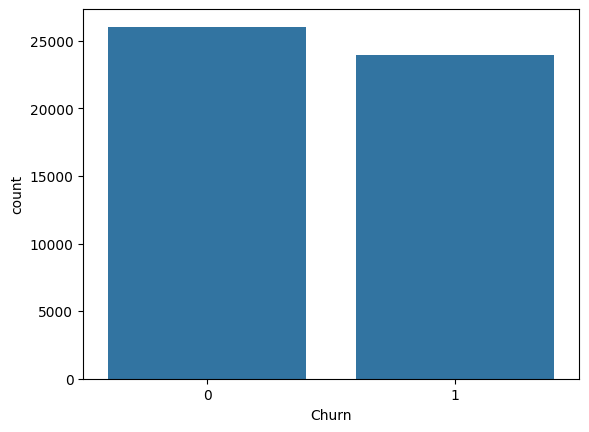

In [6]:
import seaborn as sns
sns.countplot(x='Churn',data=df)

In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier

from sklearn.ensemble import StackingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

import matplotlib.pyplot as plt

<Axes: xlabel='Income', ylabel='Count'>

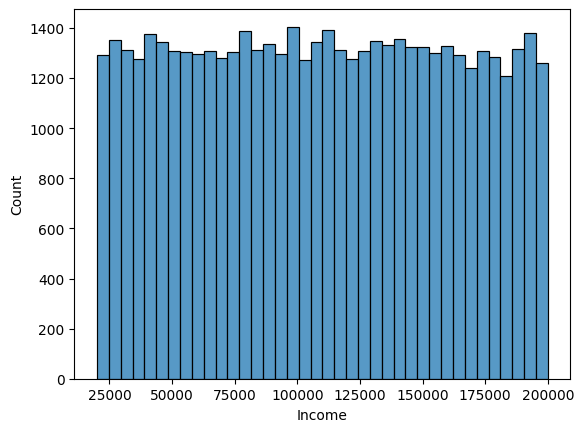

In [8]:
sns.histplot(df['Income'])

<Axes: >

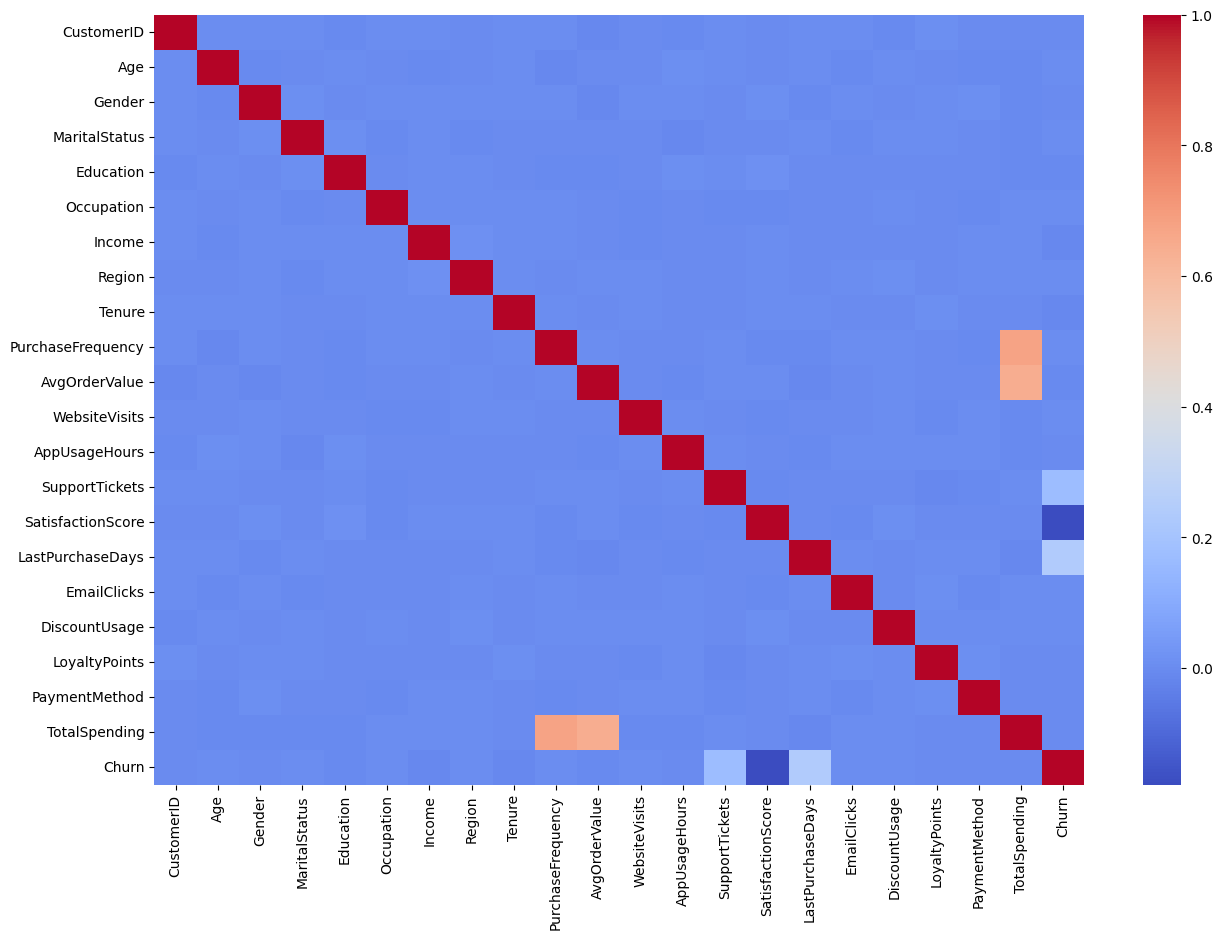

In [9]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    annot=False,
    cmap='coolwarm'
)

In [10]:
df['CLV'] = (
    df['TotalSpending']
    *
    df['Tenure']
)/1000

In [11]:
df['EngagementScore'] = (
      df['WebsiteVisits']
    + df['EmailClicks']
    + df['LoyaltyPoints']/100
)

In [12]:
df['CustomerScore'] = (
      0.3*df['Income']
    + 0.3*df['PurchaseFrequency']
    + 0.4*df['SatisfactionScore']
)

In [13]:
X = df.drop(
    ['CustomerID','Churn'],
    axis=1
)

y = df['Churn']

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [15]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
LogisticRegression()

LogisticRegression()

In [17]:
RandomForestClassifier(
    n_estimators=300
)

RandomForestClassifier(n_estimators=300)

In [18]:
AdaBoostClassifier(
    n_estimators=300
)

AdaBoostClassifier(n_estimators=300)

In [19]:
XGBClassifier(
    n_estimators=300,
    max_depth=6
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [20]:
estimators = [

 ('rf',
  RandomForestClassifier(
      n_estimators=300
  )),

 ('ada',
  AdaBoostClassifier(
      n_estimators=300
  )),

 ('xgb',
  XGBClassifier())
]

In [21]:
meta = LogisticRegression()

In [22]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(

    estimators=estimators,

    final_estimator=meta,

    cv=5
)

stack.fit(X_train,y_train)

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier(n_estimators=300)),
                               ('ada', AdaBoostClassifier(n_estimators=300)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_...
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression())

In [23]:
pred_stack = stack.predict(X_test)

In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df['Segment'] = kmeans.fit_predict(X)

In [25]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.2,
    min_samples=10
)

df['DBSCAN'] = dbscan.fit_predict(X)

In [26]:
high_value = df[
    df['CLV']
    >
    df['CLV'].quantile(0.9)
]

In [28]:
test_indices = y_test.index
df_test = df.loc[test_indices]
high_risk = df_test[pred_stack == 1]

In [29]:
def recommendation(row):

    if row['CLV'] > 100000:
        return "VIP Retention"

    elif row['Segment'] == 0:
        return "Premium Membership"

    elif row['Segment'] == 2:
        return "Discount Offer"

    else:
        return "Regular Marketing"

In [30]:
df['Recommendation'] = df.apply(
    recommendation,
    axis=1
)

In [31]:
churn_rate = (
    df['Churn'].mean()*100
)

In [32]:
avg_clv = df['CLV'].mean()

In [33]:
df['Segment'].value_counts()

,count
Segment,
0,10260
3,10190
1,10002
4,9850
2,9698


In [34]:
top_customers = df.sort_values(
    'CLV',
    ascending=False
).head(20)

In [36]:
print(f"The churn rate is: {churn_rate:.2f}%")
print(f"The average Customer Lifetime Value (CLV) is: {avg_clv:.2f}")
print("\nTop 20 Customers by CLV:")
print(top_customers[['CustomerID', 'CLV', 'TotalSpending', 'Tenure']])

The churn rate is: 47.93%
The average Customer Lifetime Value (CLV) is: 11583.53

Top 20 Customers by CLV:
       CustomerID        CLV  TotalSpending  Tenure
8320         8321  86325.260         731570     118
9588         9589  86059.729         723191     119
29918       29919  84140.252         725347     116
25023       25024  83406.624         700896     119
49644       49645  83168.288         716968     116
36641       36642  82233.792         708912     116
8345         8346  81846.072         717948     114
3624         3625  81030.432         680928     119
6656         6657  80188.016         691276     116
9807         9808  79893.471         719761     111
10464       10465  79610.544         680432     117
34043       34044  79433.352         673164     118
4389         4390  79149.700         682325     116
27281       27282  78776.564         667598     118
1126         1127  78534.144         671232     117
22472       22473  78419.712         700176     112
24726    

In [38]:
numeric_df = df.drop(columns=['CustomerID', 'Recommendation'])
print("Correlations with 'Churn' (absolute values):")
print(numeric_df.corr()['Churn'].abs().sort_values(ascending=False).drop('Churn'))

print("\nInterpretation for Improvement:\n")
print("To improve customer retention (reduce churn), consider focusing on:")
print("- Increasing 'SatisfactionScore' (strong negative correlation with Churn).")
print("- Increasing 'Tenure' (strong negative correlation with Churn).")
print("- Increasing 'CLV' (strong negative correlation with Churn).")
print("- Decreasing 'LastPurchaseDays' (strong positive correlation with Churn). This means encouraging more frequent recent purchases.")
print("- Decreasing 'SupportTickets' (positive correlation with Churn). This implies improving customer support to reduce the need for tickets.")
print("The heatmap visually represents these relationships, with stronger correlations (positive or negative) appearing as more intense colors further from zero on the color scale.")

Correlations with 'Churn' (absolute values):
LastPurchaseDays     0.238607
SatisfactionScore    0.178481
SupportTickets       0.170079
Tenure               0.010086
CustomerScore        0.008204
Income               0.008192
CLV                  0.007407
AvgOrderValue        0.006554
MaritalStatus        0.004785
Age                  0.004331
DiscountUsage        0.004207
WebsiteVisits        0.004178
Education            0.003910
EngagementScore      0.003823
EmailClicks          0.003435
TotalSpending        0.002846
Occupation           0.002489
PurchaseFrequency    0.002407
Region               0.002248
LoyaltyPoints        0.000981
Gender               0.000788
PaymentMethod        0.000606
AppUsageHours        0.000245
Segment              0.000027
DBSCAN                    NaN
Name: Churn, dtype: float64

Interpretation for Improvement:

To improve customer retention (reduce churn), consider focusing on:
- Increasing 'SatisfactionScore' (strong negative correlation with Churn).
